# Profile-likelihood CIs — Wald vs. profile vs. sandwich

The default `confint(level=0.95)` on a `tram` fit returns the *Wald*
interval

$$
\hat\theta_j \;\pm\; z_{1-\alpha/2}\,\sqrt{V_{jj}},
$$

where $V = \text{vcov}() = -H^{-1}$ is the inverse observed information.
Two assumptions are baked in: the log-likelihood is locally a
well-conditioned paraboloid around $\hat\theta$, and that paraboloid is
*symmetric*.  Both can fail — most visibly when the MLE sits on (or near)
an active monotonicity boundary, which is the typical situation for the
Bernstein coefficients of a small-$n$ baseline transformation.

mltpy 0.4 exposes two non-Wald alternatives on the same `confint()`
method (`type="profile"`) and `sandwich_se()` helper:

* **Profile likelihood** — `confint(type="profile")` inverts the
  $\chi^2_1$ likelihood-ratio test by re-fitting the constrained model
  with $\theta_j$ pinned to a sweep of values and root-finding for
  $2\,(\hat\ell - \ell_p(v)) = \chi^2_{1,1-\alpha}$.  Honours likelihood
  asymmetry; pays roughly ten constrained refits per parameter.
* **Sandwich** — `sandwich_se()` returns the HC0 estimator
  $V_{\text{sand}} = B\,M\,B$ with $B = -H^{-1}$ and
  $M = \sum_i s_i s_i^\top$, robust to mild mis-specification of the
  outcome distribution.  We assemble the symmetric CI manually as
  $\hat\theta_j \pm z_{1-\alpha/2}\sqrt{V_{\text{sand},jj}}$.

This vignette compares all three on the right-censored Coxph fixture
from `reference/vcov_coxph_*` — the same dataset that the R-parity
tests in `tests/test_confidence.py` check element-wise against
`tram::Coxph(Surv(y, event) ~ x)`.  The Bernstein MLE has
`Bs1 = Bs2 = Bs3` stacked on the monotonicity boundary, so the Wald
approximation breaks down on those baseline coefficients while the
well-identified covariate $\beta_x$ remains a regular-asymptotics
story where all three agree.

Below we render two figures: a forest plot of the three intervals
side-by-side, then the profile log-likelihood curve for the most
asymmetric parameter with all CI endpoints annotated.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2, norm

from mltpy.model import ConvergenceWarning
from mltpy.tram import Coxph
from mltpy.variables import CensoredData

# Profile-CI refits a constrained likelihood ~10× per parameter; the inner
# auglag occasionally hits the outer-iteration cap on Bernstein-boundary
# pins and emits ConvergenceWarning (see CLAUDE.md, _PROFILE_INNER_KKT_THRESHOLD).
# The vignette is informational, not a parity test, so we silence them.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams["figure.dpi"] = 110
REF_DIR = Path("../../reference")  # repo-relative path to reference fixtures

## 1. The fitted model

Right-censored Coxph fit on $n = 200$ observations with one continuous
covariate.  Loading the dataset from `reference/` rather than
re-synthesising means the CI tables below are *the same numbers* the
R-parity tests check against — `tram::Coxph` agrees to ~1e-3 on every
row of both `confint(type='wald')` and `confint(type='profile')`.

In [2]:
y = np.loadtxt(REF_DIR / "vcov_coxph_y.txt")
x = np.loadtxt(REF_DIR / "vcov_coxph_x.txt").reshape(-1, 1)
event = np.loadtxt(REF_DIR / "vcov_coxph_event.txt").astype(int)
a, b = (float(v) for v in np.loadtxt(REF_DIR / "vcov_coxph_support.txt"))

cd = CensoredData.right_censored(y, censored=event == 0)
model = Coxph(support=(a, b), order=4).fit(cd, X=x)

param_names = [f"Bs{i}" for i in range(5)] + ["x"]
ll_hat = model.score(cd, X=x)

print(f"n = {len(y)}, events = {int(event.sum())}, censored = {(event == 0).sum()}")
print(f"log-likelihood at MLE = {ll_hat:.4f}")
print("theta_hat:")
for name, th in zip(param_names, model.theta_):
    print(f"  {name:>4} = {th:+.4f}")

n = 200, events = 147, censored = 53
log-likelihood at MLE = -168.1675
theta_hat:
   Bs0 = -2.4380
   Bs1 = +1.1091
   Bs2 = +1.1091
   Bs3 = +1.1091
   Bs4 = +1.8148
     x = +0.2383


Notice `Bs1 = Bs2 = Bs3 ≈ 1.109` — three consecutive Bernstein
coefficients have collapsed onto the monotonicity boundary
$\theta_{k+1} \ge \theta_k$.  Equality-active constraints make the
observed information singular along the boundary direction, and the
Wald CI is the diagnostic that catches it most loudly.

## 2. Wald, profile, and sandwich side-by-side

All three share `confint`'s coverage target (95 %) and the same
$\hat\theta$.  They differ only in how they convert the local
likelihood geometry into an interval:

* **Wald** — `confint(type="wald")`: symmetric, uses
  $\sqrt{V_{jj}} = \sqrt{(-H^{-1})_{jj}}$.
* **Profile** — `confint(type="profile")`: inverts the LR test,
  asymmetric in general.
* **Sandwich** — assembled by hand as
  $\hat\theta_j \pm z_{0.975}\,\sqrt{V_{\text{sand},jj}}$ using
  `sandwich_se()`.  Still symmetric; the only thing it replaces is
  the variance estimator.

In [3]:
ci_wald = model.confint(level=0.95, type="wald")
ci_prof = model.confint(level=0.95, type="profile")
se_sand = model.sandwich_se()
z = float(norm.ppf(0.975))
ci_sand = np.column_stack((model.theta_ - z * se_sand, model.theta_ + z * se_sand))

ci_table = pd.DataFrame(
    {
        "theta_hat": model.theta_,
        "wald_lo": ci_wald[:, 0],
        "wald_hi": ci_wald[:, 1],
        "prof_lo": ci_prof[:, 0],
        "prof_hi": ci_prof[:, 1],
        "sand_lo": ci_sand[:, 0],
        "sand_hi": ci_sand[:, 1],
    },
    index=param_names,
).round(3)
ci_table

,theta_hat,wald_lo,wald_hi,prof_lo,prof_hi,sand_lo,sand_hi
Bs0,-2.438,-2.819,-2.057,-2.810,-2.092,-2.621,-2.255
Bs1,1.109,0.408,1.811,0.889,1.320,0.452,1.767
Bs2,1.109,0.008,2.210,0.889,1.320,0.056,2.162
Bs3,1.109,0.145,2.073,0.889,1.373,0.152,2.066
Bs4,1.815,1.179,2.450,1.303,2.518,1.421,2.208
x,0.238,0.077,0.400,0.080,0.400,0.072,0.404


Two patterns to read out of the table:

1. **Covariate `x` (the proportional-hazards $\beta$)** — all three
   intervals agree to $\approx 0.01$.  $\beta_x$ is well-identified by
   147 uncensored events, the Hessian is regular in its direction, and
   the likelihood is locally quadratic and symmetric.  This is the
   textbook regularity case.
2. **Bernstein coefficients `Bs1`–`Bs3`** — the Wald widths
   (1.40, 2.20, 1.93) are 3–5× wider than the profile widths
   ($\approx 0.43$).  Sandwich barely helps: it inherits the same
   bread $V$ and only reweights it.  When the bread itself is
   near-singular along an active monotonicity row, no rescaling will
   recover a sensible interval.  Profile sidesteps the issue entirely
   by *refitting* under the pin, so the active-constraint geometry
   propagates correctly.

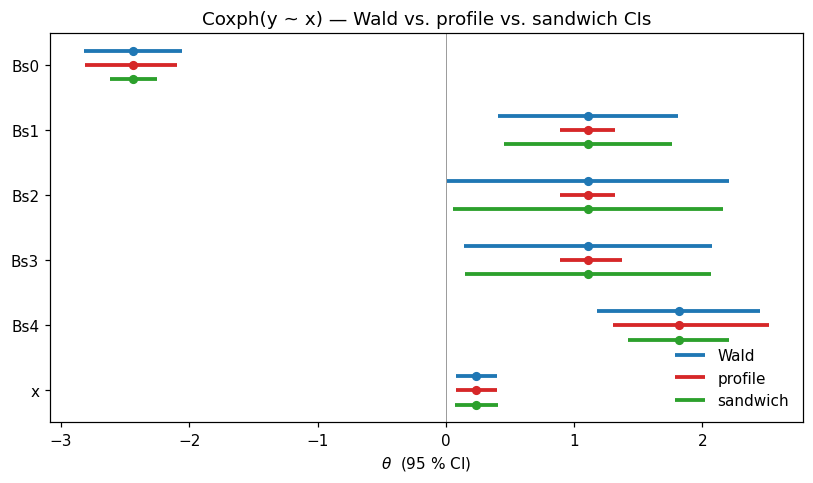

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
positions = np.arange(len(model.theta_))
offset = 0.22


def _band(ax, pos, ci, theta_hat, color, label):
    ax.hlines(pos, ci[:, 0], ci[:, 1], color=color, linewidth=2.5, label=label)
    ax.plot(theta_hat, pos, "o", color=color, markersize=5)


_band(ax, positions - offset, ci_wald, model.theta_, "#1f77b4", "Wald")
_band(ax, positions, ci_prof, model.theta_, "#d62728", "profile")
_band(ax, positions + offset, ci_sand, model.theta_, "#2ca02c", "sandwich")
ax.set_yticks(positions)
ax.set_yticklabels(param_names)
ax.invert_yaxis()
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(r"$\theta$  (95 % CI)")
ax.set_title("Coxph(y ~ x) — Wald vs. profile vs. sandwich CIs")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
plt.show()

## 3. The profile log-likelihood for the most asymmetric parameter

The forest plot above shows Wald and profile have the same *centre*
($\hat\theta$) but different *widths*.  A finer diagnostic is whether
the profile interval is itself asymmetric around $\hat\theta$ — i.e.
the curvature of $\ell_p$ differs on either side.  Compute the
left / right halves of each profile CI:

In [5]:
asym = []
for j in range(len(model.theta_)):
    th = float(model.theta_[j])
    lo, hi = ci_prof[j]
    left = th - lo
    right = hi - th
    skew = (right - left) / (right + left)
    asym.append((param_names[j], left, right, skew))

asym_df = pd.DataFrame(
    asym, columns=["param", "left_half", "right_half", "skew"]
).round(3)
asym_df

,param,left_half,right_half,skew
0,Bs0,0.372,0.346,-0.037
1,Bs1,0.220,0.211,-0.020
2,Bs2,0.220,0.211,-0.020
3,Bs3,0.220,0.264,0.090
4,Bs4,0.512,0.703,0.157
5,x,0.158,0.162,0.012


In [6]:
j_star = int(np.argmax([abs(s) for *_, s in asym]))
print(
    f"most asymmetric parameter: {param_names[j_star]}  "
    f"(skew = {asym[j_star][3]:+.3f}, "
    f"right half {asym[j_star][2] / asym[j_star][1]:.2f}× left half)"
)

most asymmetric parameter: Bs4  (skew = +0.157, right half 1.37× left half)


`_profile_loglik_at(j, v)` returns the maximised log-likelihood under
the constraint $\theta_j = v$, refitting the remaining $p + q - 1$
parameters under the model's monotonicity constraints (see CLAUDE.md
for the contract).  It is the building block `_confint_profile` calls
from `confint(type="profile")`; surfacing the curve here is purely a
diagnostic — `_profile_loglik_at` remains private API and the
supported entry point is `confint(type="profile")`.  Sweep it on a
fine grid that brackets both the profile and the Wald endpoints:

In [7]:
crit_95 = float(chi2.ppf(0.95, df=1))  # 3.84
lo_p, hi_p = ci_prof[j_star]
lo_w, hi_w = ci_wald[j_star]
pad = 0.15 * (hi_p - lo_p)
v_grid = np.linspace(min(lo_p, lo_w) - pad, max(hi_p, hi_w) + pad, 41)
ll_grid = np.array([model._profile_loglik_at(j_star, float(v)) for v in v_grid])
twice_diff = 2.0 * (ll_hat - ll_grid)

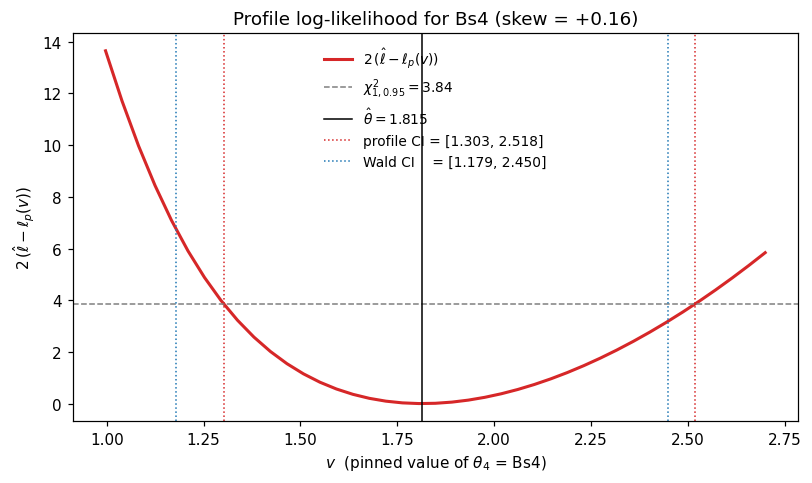

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(v_grid, twice_diff, color="#d62728", lw=2, label=r"$2\,(\hat\ell - \ell_p(v))$")
ax.axhline(crit_95, color="grey", lw=1, ls="--", label=r"$\chi^2_{1,0.95} = 3.84$")
ax.axvline(
    model.theta_[j_star],
    color="black",
    lw=1,
    label=rf"$\hat\theta = {model.theta_[j_star]:.3f}$",
)
ax.axvline(
    lo_p, color="#d62728", lw=1, ls=":", label=rf"profile CI = [{lo_p:.3f}, {hi_p:.3f}]"
)
ax.axvline(hi_p, color="#d62728", lw=1, ls=":")
ax.axvline(
    lo_w, color="#1f77b4", lw=1, ls=":", label=rf"Wald CI    = [{lo_w:.3f}, {hi_w:.3f}]"
)
ax.axvline(hi_w, color="#1f77b4", lw=1, ls=":")
ax.set_xlabel(rf"$v$  (pinned value of $\theta_{{{j_star}}}$ = {param_names[j_star]})")
ax.set_ylabel(r"$2\,(\hat\ell - \ell_p(v))$")
ax.set_title(
    f"Profile log-likelihood for {param_names[j_star]} (skew = {asym[j_star][3]:+.2f})"
)
ax.legend(frameon=False, loc="upper center", fontsize=9)
fig.tight_layout()
plt.show()

Three things to read off the plot:

* The curve crosses the dashed $\chi^2_{1,0.95}$ cutoff at the two
  *red dotted* lines — these are the profile-CI endpoints by
  construction (`_confint_profile` solves exactly
  $2\,(\hat\ell - \ell_p(v)) - 3.84 = 0$ on each side via
  `scipy.optimize.brentq`).
* The right arm of the profile curve is visibly flatter than the
  left, which is exactly what the positive skew in the table records.
  A symmetric Wald paraboloid (blue dotted endpoints) misses this:
  the upper Wald endpoint sits *inside* the profile region while the
  lower Wald endpoint sits *outside* it.
* On `Bs4`, profile is shifted *to the right* relative to Wald — the
  baseline coefficient can take values further above $\hat\theta$
  than the symmetric approximation allows, because the only thing
  shrinking the right tail is the next-up boundary $\theta_4$ has
  little neighbour to push against.

## 4. When to prefer each interval type

| | Cost per parameter | Honours asymmetry | Robust to mis-specified link | Robust to active constraints |
|---|---|---|---|---|
| **Wald** | one inversion of $H$ at $\hat\theta$ | no | no | **no** — fails on monotonicity boundaries |
| **Sandwich** | one inversion of $H$ + one $s s^\top$ accumulation | no | **yes** | no — same singular bread as Wald |
| **Profile** | $\approx$ 10 constrained refits | **yes** | partially (still uses $\ell$) | **yes** — refits under the pin |

Practical rules of thumb that follow from the table:

* Default to Wald for fast triage and well-identified covariates
  ($\beta_x$ above: all three methods agreed to 0.01).
* Reach for sandwich when you suspect distributional mis-specification
  — heavy tails relative to the base distribution, residual
  heteroskedasticity not captured by `scaling=`, etc.  See also the
  [`scaling-terms vignette`](05_scaling_terms.ipynb) for explicit
  modelling of heteroskedasticity, which often is the better answer
  than sandwiching.
* Reach for profile when (i) the Wald and sandwich CIs disagree on
  width despite the link looking right, (ii) the parameter sits near
  a boundary (Bernstein coefficients, scaling $\gamma$ at the
  identification frontier, etc.), or (iii) you need to report a CI
  that you can defend as inversion of the LR test.  Pay the extra
  ~10× cost on a `parm=[j]` subset rather than the full vector unless
  $p + q$ is small.

Profile and Wald CIs are R-parity tested against `tram::Coxph` /
`tram::BoxCox` / `tram::Colr` in `tests/test_confidence.py` to
`rtol = 1e-3`; the sandwich estimator is checked against
`sandwich::vcovHC(..., type = "HC0")` in the same file.